# __Demo 2 - NDVI raster analysis__ [Work in progress]
### Basic usage example of processing and representing Normalized Difference Vegetation Index (NDVI) analysis data

#### __What is NDVI?__
The Normalized Difference Vegetation Index (NDVI) is a spectral index that measures vegetation greenness and vigor. It is calculated using the difference between near-infrared (NIR) and red reflectance values divided by their sum:

$$
NDVI = \frac{(NIR - RED)}{(NIR + RED)}
$$

Healthy vegetation strongly reflects NIR light and absorbs visible red light for photosynthesis, resulting in high NDVI values (close to +1). Bare soil or urban areas typically have values near 0, while water or non-vegetated surfaces may have negative values.

#### __How can NDVI be used?__
NDVI is widely used in environmental monitoring, agriculture, and urban planning. It helps data scientists and researchers to:

* Detect and map areas with live green vegetation.
* Monitor crop growth, drought conditions, and deforestation.
* Assess land degradation and ecosystem health over time.
* Support climate change studies and disaster response (e.g., wildfire burn severity or flood recovery).
* Analyze temporal dynamics of vegetation using satellite imagery time series.

#### __About this notebook__
This notebook displays a __demo process to be used be used to calculate NDVI__ within a given area of interest, __and then represent the data__ using Observatory's design style.

The notebook consists of the following steps:
* __Import libraries__
* __Analysis configuration__
* __Homogenize the input data's CRS for the analysis__
* __Download OSM roads and intersections__
* __Calculate proximity from each node to the points of interest__
* __Proximity analysis to hexgrid__
* __Proximity visualization__

## __Import libraries__

In order to use the functions required to process and represent data, we've developed a code library called `odc`, which stores functions that use other python libraries for the analysis and representation of data.

In [2]:
import func_timeout
print(func_timeout.__version__)

4.3.5


In [1]:
from pathlib import Path
current_path = Path().resolve()
for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break
print(project_root)

import os
import sys

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

/home/jovyan/odc
Path found


In [2]:
import pandas as pd
import geopandas as gpd
#import odc
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

## __Analysis configuration__

This cell specifies the location of input data and other parameters used within the proximity analysis.

In [3]:
# --------------- Location of input data
# Area of interest - Directory with location of input layer containing a polygon geometry that defines the area of interest were the analysis is to be performed.
aoi_dir = "../data/demo_files/aoibuffer_saltillo_32614.gpkg"

# --------------- Analysis parameters
# index_analysis (str) - Index to be analysed
index_analysis = "NDVI" 
# aoi_name (str) - Name of area of interest
aoi_name = 'Saltillo'
# start_date (str) - Stard date for the analysis in format "YYYY-MM-DD"
start_date = "2025/01/01"
# end_date (str) - End date for the analysis in format "YYYY-MM-DD"
end_date = "2025/05/31"
# tmp_dir (str) Temporary directory where raster data will be saved
tmp_dir = "../data/demo_files/ndvi_process"
# projection_crs (str) - CRS used when projecting features to perform geoprocessing (e.g. "6372" could be used anywere in Mexico)
# [Optional, function defaults to "EPSG:6372"]
projection_crs = "EPSG:32614"
# band_name_dict (dict) - Dictionary with spectral band names (example for Sentinel-2 NDVI). If bands are provided by satellite in different resolutions, must set dict values to [True] instead of [False]
band_name_dict= {"nir": [False],  # Near-infrared band
                 "red": [False],  # Red band
                }
# index_equation (lst) - List with equation for index calculation using common band names (example for Sentinel-2 NDVI)
index_equation = ["(nir-red)/(nir+red)"]

# --------------- Output saving
# Output directory for hexagons (str) - Directory with the location where the output hexs with raster analysis will be saved
output_dir = "../data/demo_files/outputs_ndvi/"

## __Homogenize the input data's CRS for the analysis__

Both the area of interest and the points of interest are __set to EPSG:4326.__

<Axes: >

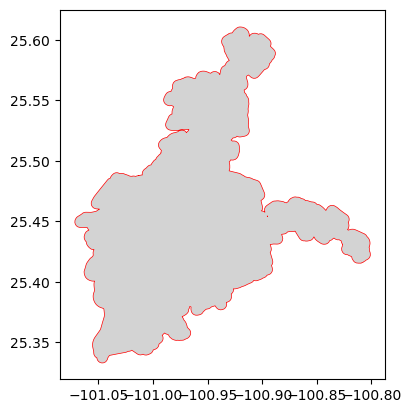

In [4]:
# --------------- Prepare the area of interest CRS
aoi_gdf = gpd.read_file(aoi_dir)
if aoi_gdf.crs is None:
    aoi_gdf = aoi_gdf.set_crs('EPSG:4326')
elif aoi_gdf.crs != 'EPSG:4326':
    aoi_gdf = aoi_gdf.to_crs('EPSG:4326')

# Show input data (This part creates the following map for visualization purposes)
fig,ax = plt.subplots()
aoi_gdf.plot(ax=ax,zorder=1, facecolor='lightgray',edgecolor='red',lw=.5)

## __Initialize PCRasterData Class__

The function __PDRasterData__ class was developed to simplify the process of adding up all variables and processes regarding the analysis of raster data.

In [5]:
raster_process = odc.PCRasterData(gdf=aoi_gdf,
                                  index_analysis=index_analysis,
                                  area_of_analysis_name=aoi_name,
                                  start_date=start_date,
                                  end_date=end_date,
                                  tmp_dir=tmp_dir,
                                  band_name_dict=band_name_dict,
                                  index_equation=index_equation,
                                  projection_crs=projection_crs,
                                  sat_query = {"eo:cloud_cover": {"lt": 15}}
                                 )

## __Execute main process__

The method __odc.download_raster_from_pc(self)__ contains the main workflow to download and process satellite raster data.

This method orchestrates the complete raster processing pipeline:
1. Creates spatial and temporal areas of interest
2. Queries Planetary Computer for available satellite imagery
3. Downloads and mosaics raster data by month
4. Calculates indices and performs quality control
5. Interpolates missing data if requested

In [6]:
df_raster_inventory = raster_process.download_raster_from_pc()

# Show
print(df_raster_inventory.shape)
df_raster_inventory.head(2)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 476.47it/s]

(5, 6)


,year,month,data_id,able_to_download,download_method,interpolate
0,2025,1,1,1.0,specific_date,0
1,2025,2,1,1.0,specific_date,0


# Other

#### __Save the nodes proximity analysis to output directory__

In [9]:
nodes_with_time.to_file(output_dir+f'nodes_with_{pois_name}_time', driver="GPKG")
print(f"Results saved to {output_dir}")

/opt/conda/envs/gds/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: File ../data/demo_files/demo_proximity/outputs/nodes_with_schools_time has GPKG application_id, but non conformant file extension
  ogr_write(


Results saved to ../data/demo_files/demo_proximity/outputs/


## __Proximity analysis to hexgrid__

#### __Create hexgrid in area of analysis__

In order to visualize a territorial analysis of proximity, the proximity analysis can be integrated into hexagons. Function __odc.create_hexagonal_grid()__ can be used to create the hexgrid.

In [10]:
hex_gdf = odc.create_hexagonal_grid(aoi_gdf, resolution=hex_res)

# Show
print(hex_gdf.crs)
print(hex_gdf.shape)
hex_gdf.head(2)

EPSG:4326
(2698, 2)


,hex_id_9,geometry
0,8948a04ceafffff,"POLYGON ((-100.92214 25.39509, -100.92085 25.3..."
1,8948a2b4b3bffff,"POLYGON ((-100.91312 25.60242, -100.91183 25.6..."


#### __Integrate proximity analysis into hexgrid__

Function __odc.group_points_by_bins()__ can be used to summarize point data to polygons specifying aggregation functions.

In [11]:
if count_pois[0]:
    aggregation_func={f'time_{pois_name}':'mean',
                      f'{pois_name}_{count_pois[1]}min':'mean'}
else:
    aggregation_func={f'time_{pois_name}':'mean'}    

hex_proximity = odc.group_points_by_bins(points=nodes_with_time,
                                         bins=hex_gdf,
                                         bin_id_column=f'hex_id_{hex_res}',
                                         aggregate_columns=list(aggregation_func.keys()),
                                         aggregation_func=aggregation_func
                                        )

# Show
print(hex_proximity.crs)
print(hex_proximity.shape)
hex_proximity.head(2)

EPSG:4326
(2698, 4)


,hex_id_9,geometry,time_schools,schools_15min
0,8948a04ceafffff,"POLYGON ((-100.92214 25.39509, -100.92085 25.3...",0.0,0.0
1,8948a2b4b3bffff,"POLYGON ((-100.91312 25.60242, -100.91183 25.6...",0.0,0.0


#### __Save the hexgrid proximity analysis to output directory__

In [12]:
hex_proximity.to_file(output_dir+f'hexs_with_{pois_name}_time', driver="GPKG")
print(f"Results saved to {output_dir}")

Results saved to ../data/demo_files/demo_proximity/outputs/


/opt/conda/envs/gds/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: File ../data/demo_files/demo_proximity/outputs/hexs_with_schools_time has GPKG application_id, but non conformant file extension
  ogr_write(


## __Proximity visualization__

#### __Visualization__ - odc.plot_proximity() just specifying column 

Function __odc.plot_proximity()__ was designed to recieve proximity data and identify the data to be plotted according to the column name.
* Passing columns with 'time' or 'max' assumes data is minutes (time) and plots divided data in 15 minutes bins.
* Passing columns with 'min' assumes data is amenity count and plots a color palette for the amount of amenities.

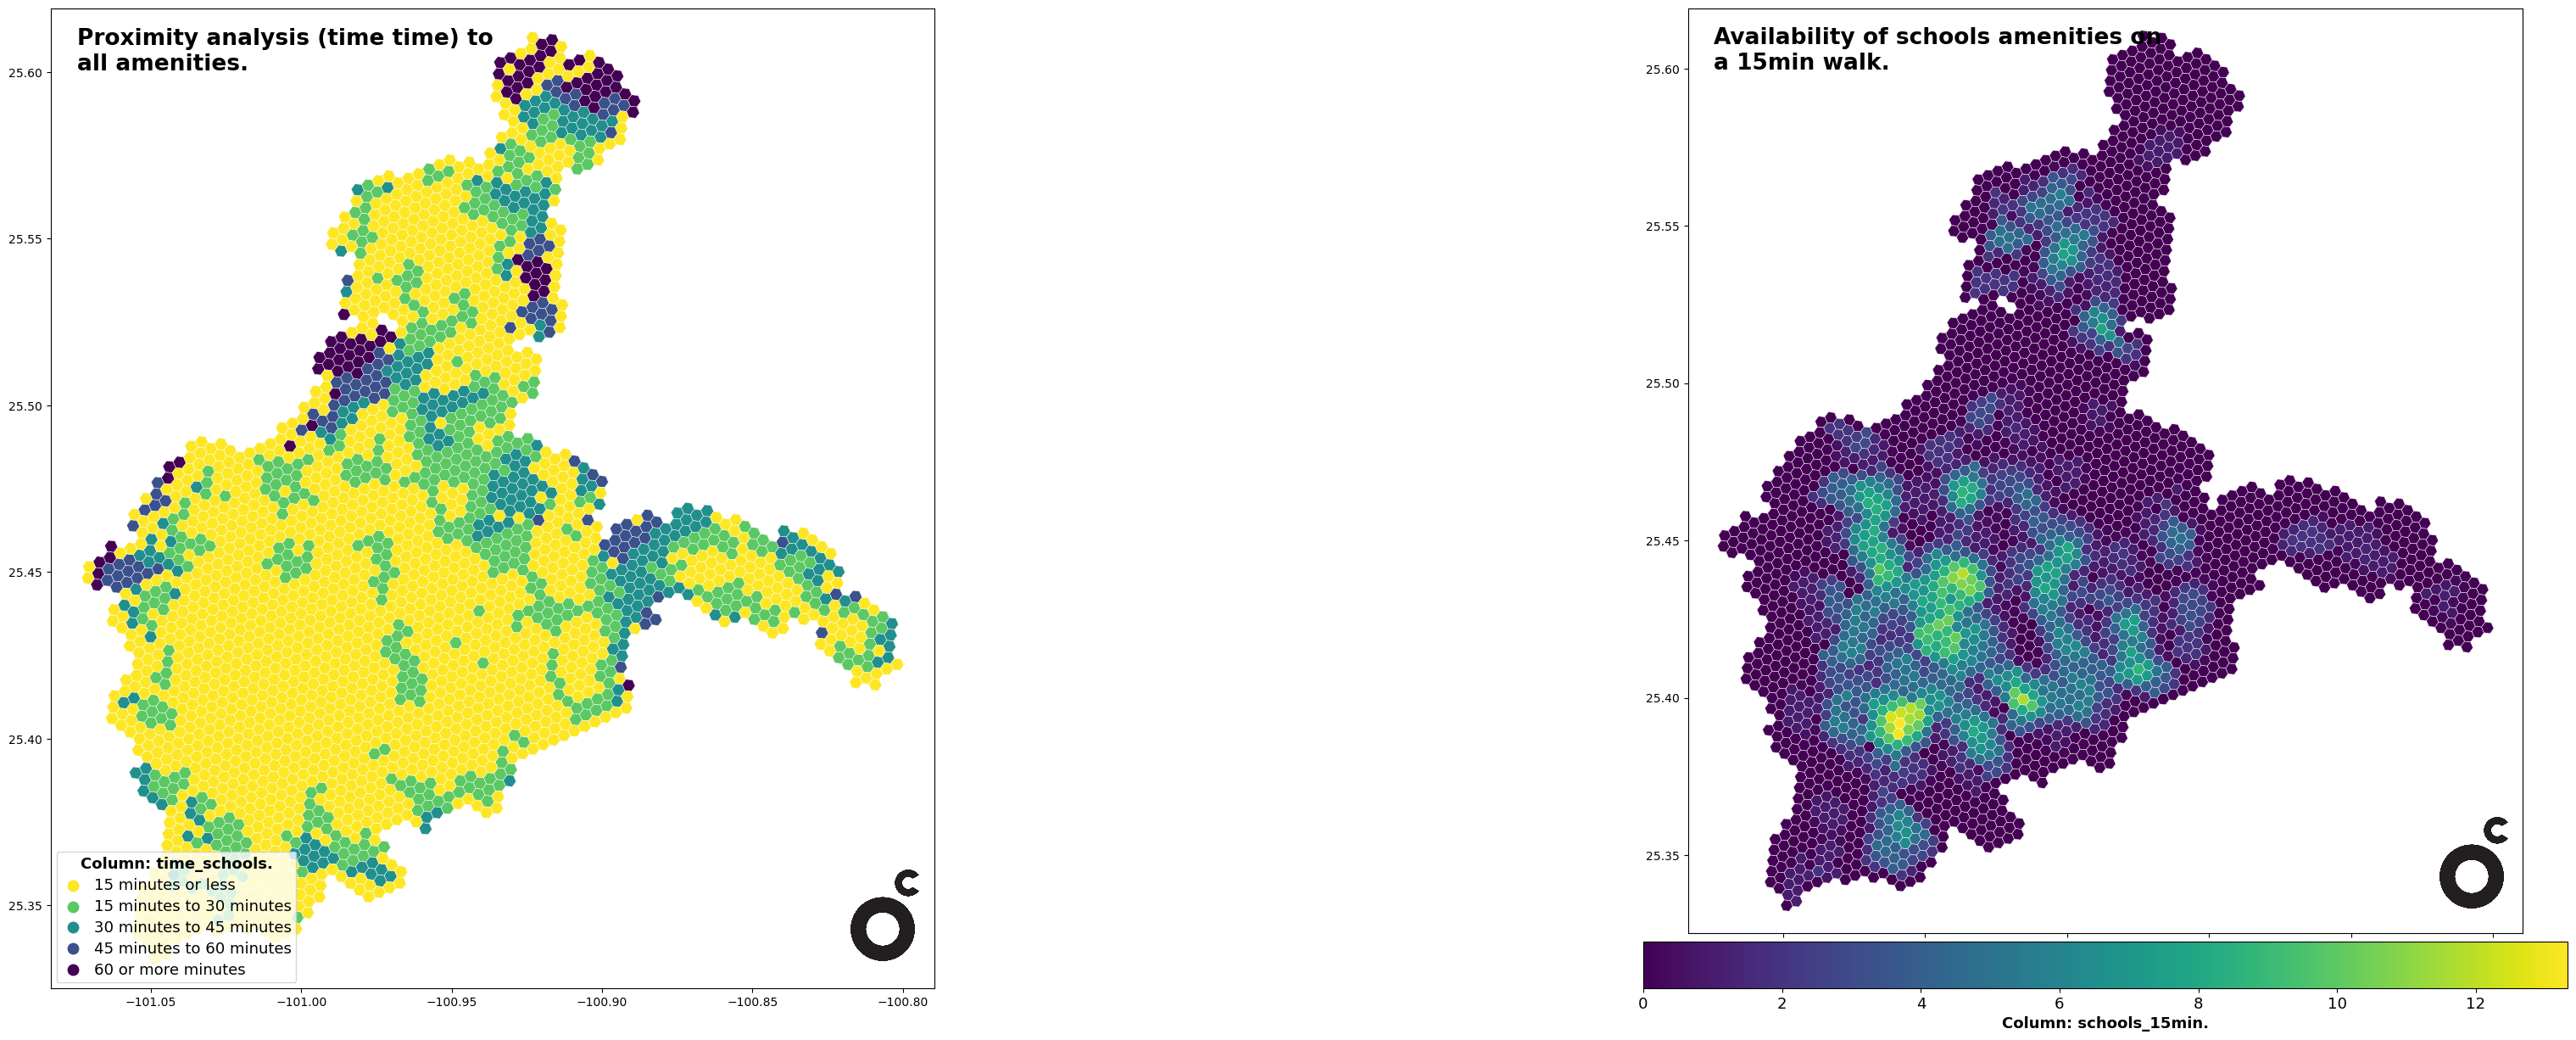

In [14]:
fig,axs = plt.subplots(1,2,figsize=(45,15))

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'time_{pois_name}',
                   ax=axs[0]
                  )

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'{pois_name}_{count_pois[1]}min',
                   ax=axs[1]
                  )

#### __Visualization__ - odc.plot_proximity() adding additional data

Keyword arguments can be added to function __odc.plot_proximity()__ to add additional data to the plot, like the __area of interest's name, and main streets.__

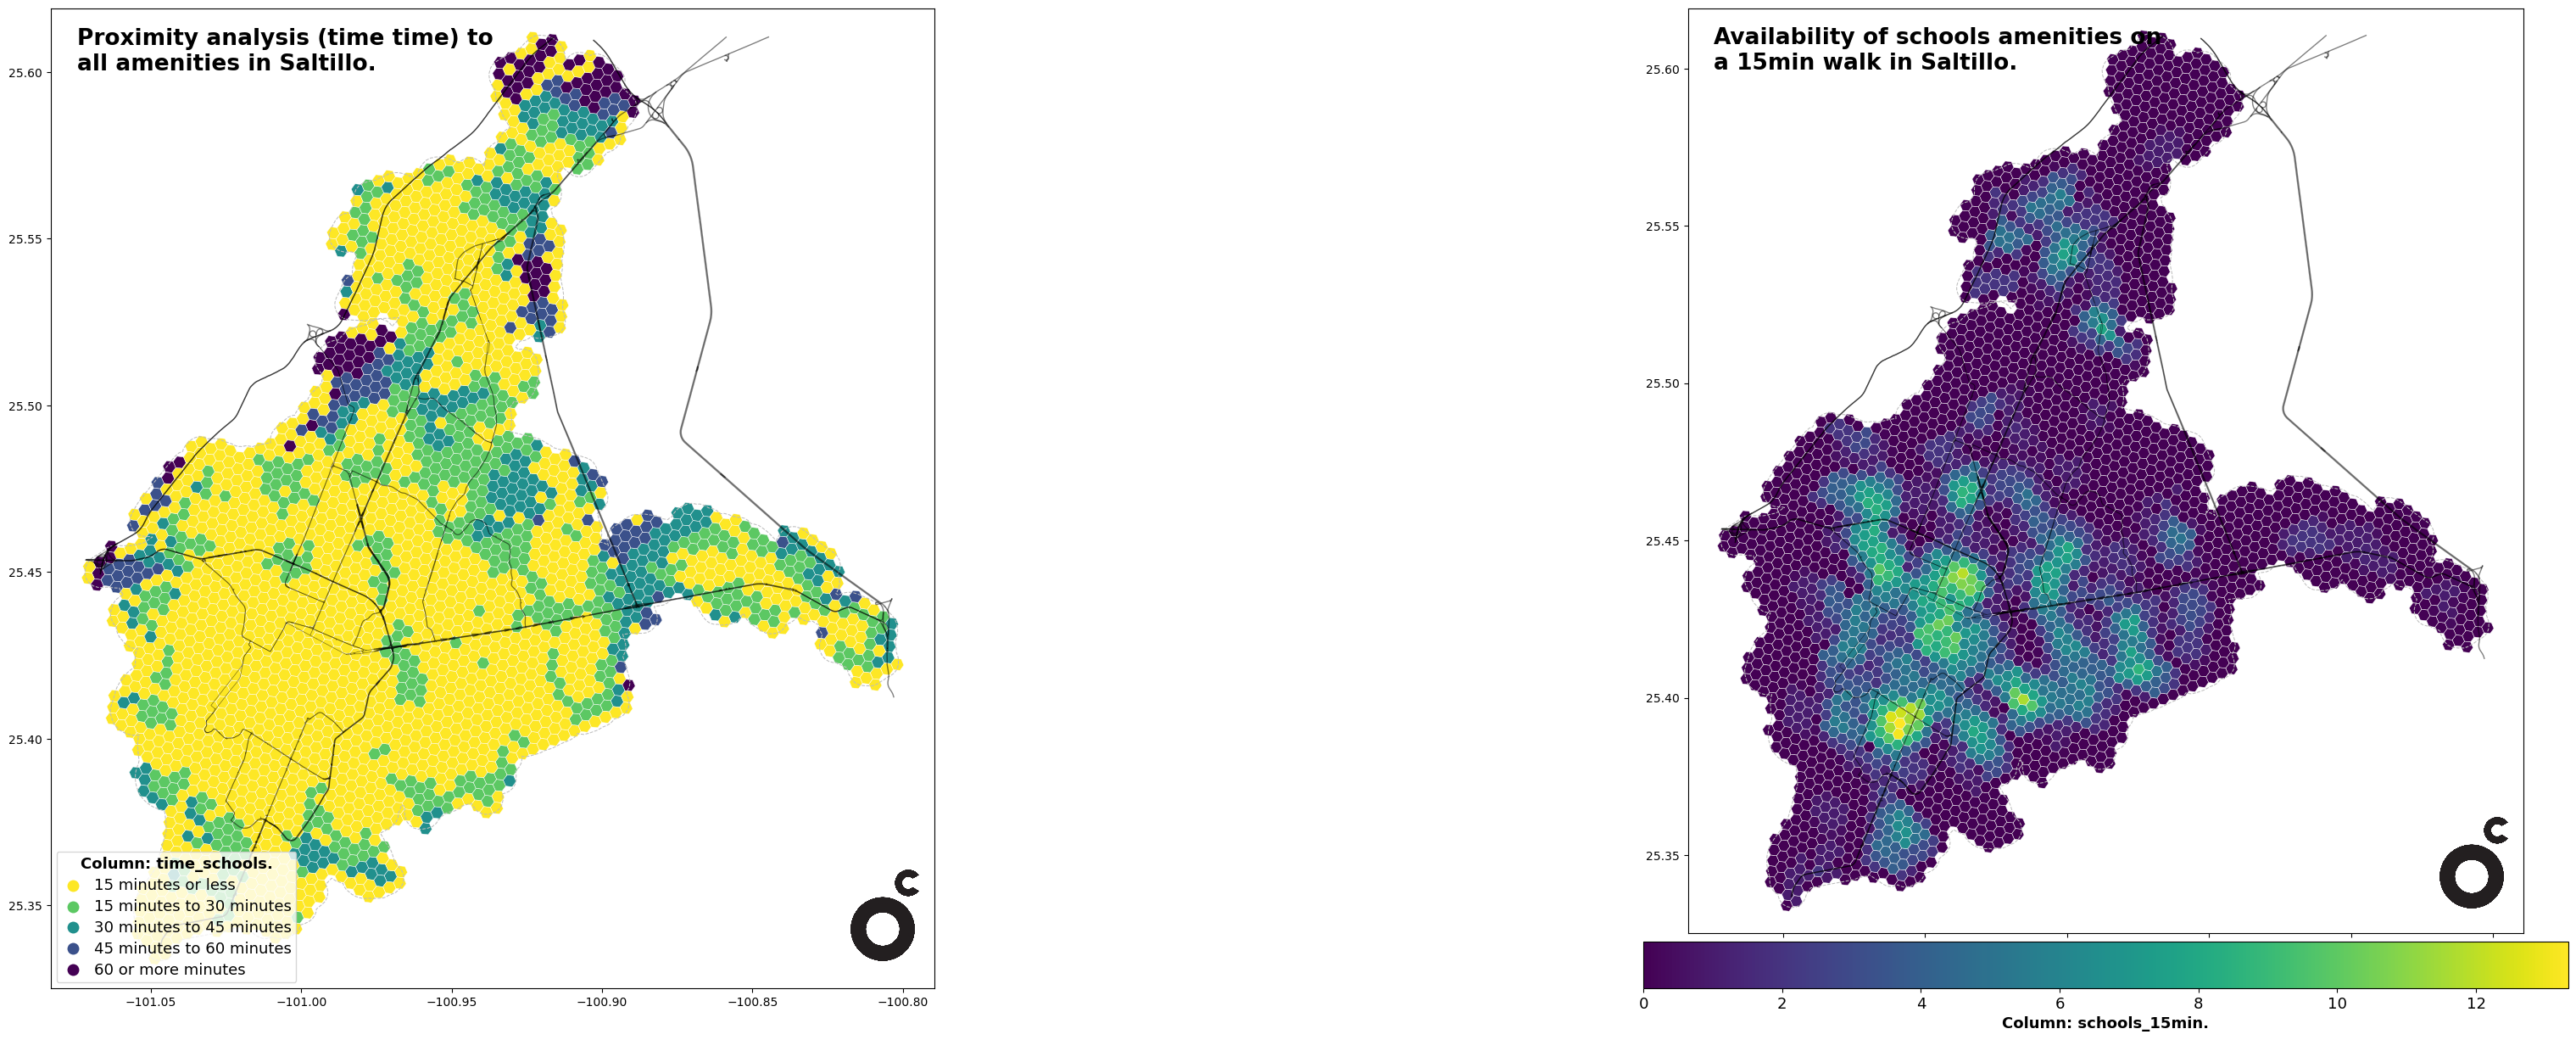

In [15]:
kwargs_dict = {"location_name":'Saltillo',
               "plot_osmnx_edges": (True, edges_gdf),
               "plot_boundary": (True, aoi_gdf),
              }

fig,axs = plt.subplots(1,2,figsize=(45,15))

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'time_{pois_name}',
                   ax=axs[0],
                   **kwargs_dict
                  )

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'{pois_name}_{count_pois[1]}min',
                   ax=axs[1],
                   **kwargs_dict
                  )